In [ ]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, cdist
from scipy.stats import pearsonr, spearmanr
# import umap.umap_ as umap
from collections import Counter
import re
import pickle
from sklearn.metrics import roc_curve, auc
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing

In [ ]:
import torch
import pandas as pd
import h5py, pickle
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

%matplotlib inline

# Figure 2 b (Figure 3.4.2 b)

In [ ]:
# rx_preprocessed_file_path = Reaxys binary activity file. A contains the activity matrix with cmpounds in the rows and species in the columns
# C contains the ECFP4 representations of the compounds
# S contains the bug embeddings of the species
# species contains the names of the species
# smiles contains the SMILES of the compounds
with h5py.File(<rx_preprocessed_file_path>, 'r') as f:
    print(f.keys())
    Y = f['A'][:]
    X_chem = f['C'][:]
    E_bug = f['S'][:]
    species = f['species'][:]
    species = np.array([s.decode('utf-8') for s in species])
    smiles = f['smiles'][:]
    smiles = np.array([s.decode('utf-8') for s in smiles])

<KeysViewHDF5 ['A', 'C', 'S', 'smiles', 'species']>


In [ ]:
Y.shape

(93781, 843)

In [ ]:
from src.utils import encode_mols, load_compound_encoder

model = load_compound_encoder()

In [ ]:
embeddings = np.array([encode_mols(sm, reduced=False, model=model) for sm in tqdm(X_chem)])

  0%|          | 0/93781 [00:00<?, ?it/s]

100%|██████████| 93781/93781 [00:33<00:00, 2811.20it/s]


In [ ]:
binary_matrix = pd.DataFrame(
    Y,
    columns=[s.lower().replace(' ','') for s in species],
    index=[s for s in smiles]
)

In [ ]:
# Take a subsample
size = 10000
if len(embeddings)>size:
    np.random.seed(42)
    indices = np.random.choice(len(embeddings), size, replace=False)
    subsampled_embeddings = embeddings[indices]
    Y = Y[indices]
    X_chem = X_chem[indices]
else:
    subsampled_embeddings = embeddings

In [ ]:
subsampled_embeddings.shape

(10000, 3072)

In [ ]:
from sklearn.manifold import TSNE

tsne_embeddings = TSNE(n_components=2, metric='cosine', n_jobs=4, init='pca', random_state=42).fit_transform(subsampled_embeddings)

df = pd.DataFrame(tsne_embeddings, columns=['TSNE1', 'TSNE2'])


In [ ]:
import matplotlib.colors as mcolors
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# cmap = plt.get_cmap('Greens')
# z_density_cmap = truncate_colormap(cmap, 0.3, 1.0)

colors = ["#FDF2E9", "#FACDB0", "#E68A56", "#B05B36", "#5D2E17"]
z_density_cmap = mcolors.LinearSegmentedColormap.from_list("Z_Density", colors)

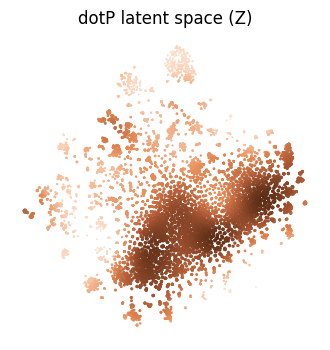

In [ ]:
from scipy.interpolate import interpn
fig, ax = plt.subplots(figsize=(4, 4))

max_size = 7
min_size = 0.5
                   
### BACKGROUND (ChEMBL) ###
x_tsne = df['TSNE1'].values
y_tsne = df['TSNE2'].values

# Density
data_e , x_e, y_e = np.histogram2d(x_tsne, y_tsne, bins = 10, density = True)
z = interpn( ( 0.65*(x_e[1:] + x_e[:-1]) , 0.65*(y_e[1:]+y_e[:-1]) ) , data_e , np.vstack([x_tsne,y_tsne]).T , method = "splinef2d", bounds_error = False)
z[np.where(np.isnan(z))] = 0.0
idx = z.argsort()
x_tsne, y_tsne, z = x_tsne[idx], y_tsne[idx], z[idx]
# Dot size
min_z = min(z)
max_z = max(z)
size = [min_size+(i-min_z)/(max_z-min_z)*(max_size-min_size) for i in z]
# Plot
ax.scatter(x_tsne, y_tsne, c=z, s=size, alpha=1, lw=0, cmap=z_density_cmap)
ax.set_axis_off()
plt.title('dotP latent space (Z)')
plt.show()

# Figure 2 c-f (Figure 3.4.2 c-f)

## Distances Rx

In [ ]:
dists_bioactivity = pdist(Y,metric='jaccard')
dists_dotp = pdist(subsampled_embeddings, metric='cosine')
dists_chem = pdist(X_chem, metric='jaccard')

## Distances ChEMBL removing molecules in Rx

In [ ]:
binary_matrix = pd.read_csv('../../data/figures_source_data/binary_activity_matrix_chembl.csv', index_col=0)

# Get equivalence between full names and codes (activity data contains the species abbreviation, not the full name)
bacterial_names = pd.read_csv('../ChEMBL_data_preprocessing/pathogens.csv')
code2name = dict(zip(bacterial_names['pathogen_code'], bacterial_names['search_text']))
binary_matrix.columns = [code2name[s] for s in binary_matrix.columns]

In [ ]:
len(np.unique(binary_matrix.index))

46066

In [ ]:
binary_matrix.head(2)

,Acinetobacter baumannii,Acinetobacter baylyi,Acinetobacter calcoaceticus,Acinetobacter calcoaceticus subsp. anitratus,Acinetobacter haemolyticus,Acinetobacter lwoffii,Acinetobacter pittii,Actinomyces israelii,Actinomyces naeslundii,Actinomyces viscosus,...,Vibrio parahaemolyticus,Vibrio splendidus,Vibrio vulnificus,Xanthomonas axonopodis,Xanthomonas campestris,Xanthomonas oryzae,Xanthomonas vesicatoria,Yersinia enterocolitica,Yersinia pestis,Yersinia pseudotuberculosis
smiles,,,,,,,,,,,,,,,,,,,,,
BrC1[C@@H](c2c[nH]c3ccccc23)c2[nH]c3ccccc3c2[C@@H]1c1c[nH]c2ccccc12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BrCCCCCOCc1c(-c2ccccc2)nc2sc3ccccc3n12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
smiles_std_chembl = binary_matrix.index.values


19043

In [ ]:
inchis_chembl = [Chem.MolToInchiKey(Chem.MolFromSmiles(s)) for s in smiles_std_chembl]

In [ ]:
inchis_rx = [Chem.MolToInchiKey(Chem.MolFromSmiles(s)) for s in smiles]

[19:01:46] unrecognized chirality tag (7) on atom 4 is ignored.
[19:02:04] Unusual charge on atom 0 number of radical electrons set to zero
[19:02:13] unrecognized chirality tag (7) on atom 4 is ignored.


In [ ]:
len(set(inchis_chembl).intersection(inchis_rx))

19150

In [ ]:
len(smiles_std_chembl)

46066

In [ ]:
mask = np.isin(inchis_chembl, inchis_rx)
binary_matrix = binary_matrix.loc[~mask,:]
binary_matrix.shape

(26916, 273)

In [ ]:
# Take a subsample
size = 10000
if len(binary_matrix)>size:
    np.random.seed(42)
    indices = np.random.choice(len(binary_matrix), size, replace=False)
    subsampled_df = binary_matrix.iloc[indices,:]
    
else:
    subsampled_df = binary_matrix

subsampled_df

,Acinetobacter baumannii,Acinetobacter baylyi,Acinetobacter calcoaceticus,Acinetobacter calcoaceticus subsp. anitratus,Acinetobacter haemolyticus,Acinetobacter lwoffii,Acinetobacter pittii,Actinomyces israelii,Actinomyces naeslundii,Actinomyces viscosus,...,Vibrio parahaemolyticus,Vibrio splendidus,Vibrio vulnificus,Xanthomonas axonopodis,Xanthomonas campestris,Xanthomonas oryzae,Xanthomonas vesicatoria,Yersinia enterocolitica,Yersinia pestis,Yersinia pseudotuberculosis
smiles,,,,,,,,,,,,,,,,,,,,,
COc1ccc(N=C(C)C2C(=O)C(N)[C@@H]3Cc4c(c(O)c5c(O)c(C)ccc5c4C)C(=O)[C@]3(O)C2=O)cc1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CCn1cc(C(=O)O)c(=O)c2cc(F)c(N3CCN(c4nnc(SCC(=O)c5ccc(Br)cc5)s4)CC3)cc21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CCOC(=O)C1=NOC(c2ccc(N3CCN(C(=O)OCC(C)C)CC3)cc2)C1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C[C@H]1[C@H](N)CN1c1nc2c(cc1F)c(=O)c(C(=O)O)cn2-c1ccc(F)cc1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CC(C)CC1NC(=O)C(Cc2ccccc2)NC(=O)C(CCN=C(N)N)NC(=O)C(NC(=O)C(CCN=C(N)N)NC(=O)C(N)C(C)O)CCNC(=O)C([C@@H](C)O)NC(=O)C(CCN=C(N)N)NC(=O)C(CCN=C(N)N)NC1=O,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCC1CN(c2cc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)CCN1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Cc1c(N2CCCC(N)C2)c(F)cn2c(=O)c(C(=O)O)cc(C3CC3)c12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CCCCCCCN=c1ccn(CCCCn2ccc(=NCCCCCCC)cc2)cc1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Y_chembl = subsampled_df.values

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
def get_ecfp4(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None  # Return zero vector for invalid SMILES
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    return fp

In [ ]:
x_chem = [get_ecfp4(sm) for sm in tqdm(subsampled_df.index)]
embeddings_chembl = np.array([encode_mols(sm, reduced=False) for sm in tqdm(x_chem)])

  0%|          | 0/10000 [00:00<?, ?it/s][19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPRECATION WARNING: please use MorganGenerator
[19:02:15] DEPR

[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerator
[19:02:16] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
embeddings_chembl.shape

(10000, 3072)

In [ ]:
dists_bioactivity_chembl = pdist(subsampled_df,metric='jaccard')
dists_dotp_chembl = pdist(embeddings_chembl, metric='cosine')

In [ ]:
dists_chem_chembl = pdist(x_chem, metric='jaccard')

## Nice plot with bioactivity distances and recapitulations for ChEMBL and Rx, sensitivity and chemistry

In [ ]:
import joblib
import numpy as np
from sklearn.metrics import roc_curve, auc

dotp_shades = ['#873e14ff', '#e68a56', '#f5ceb7ff']
chem_shades = ['#5b4763ff',  '#93779eff','#d0c3d6ff']

# Define what to calculate
configs = [
    ('ax1', dists_bioactivity, dists_dotp, [1, 10, 15], dotp_shades),
    ('ax2', dists_bioactivity, dists_chem, [1, 10, 15], chem_shades),
    ('ax3', dists_chem, dists_dotp, [0.5, 1, 5], dotp_shades),
    ('ax5', dists_bioactivity_chembl, dists_dotp_chembl, [1, 10, 15], dotp_shades),
    ('ax6', dists_bioactivity_chembl, dists_chem_chembl, [1, 10, 15], chem_shades),
    ('ax7', dists_chem_chembl, dists_dotp_chembl, [0.5, 1, 5], dotp_shades)
]

processed_results = {}

for name, d_true, d_pred, percentiles, shades in configs:
    curves = []
    for i, p in enumerate(percentiles):
        threshold = np.percentile(d_true, p)
        y_true = (d_true <= threshold).astype(int)
        fpr, tpr, _ = roc_curve(y_true, 1 - d_pred)
        curves.append({
            'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr), 
            'p': p, 'color': shades[i]
        })
    processed_results[name] = curves

# Add the raw histogram data too
processed_results['hist_rx'] = dists_bioactivity
processed_results['hist_chembl'] = dists_bioactivity_chembl

Variables saved to plot_data_cache.pkl


/tmp/ipykernel_3616309/3631239521.py:40: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_3616309/3631239521.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig('/aloy/home/grojas/tesis/antibiotics/final_pipeline/paper/fig2/recapitulation_dotP_chembl_vs_rx_whole_datasets.svg', dpi=300, bbox_inches='tight', format='svg')
/aloy/home/grojas/anaconda3/envs/ersilia/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


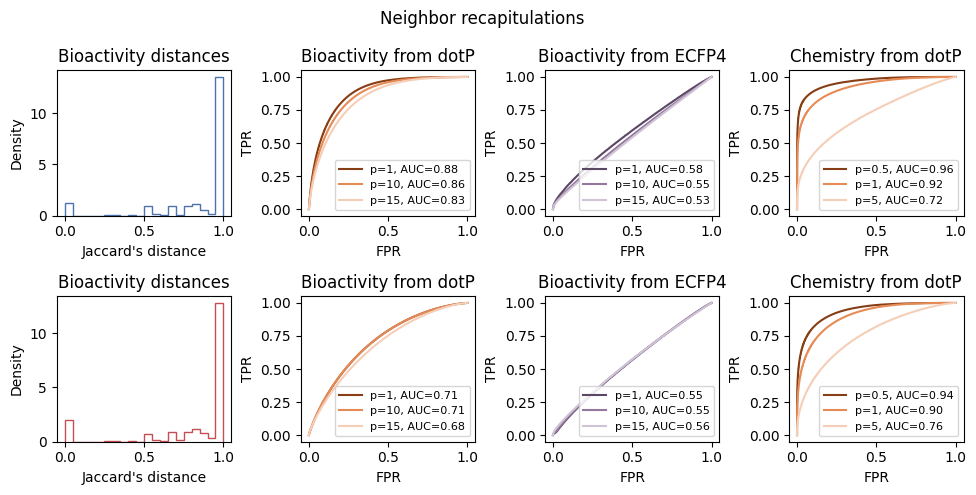

In [ ]:
import joblib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, figsize=(10, 5))
axes = ax.flatten()

# --- Distribution Plots ---
axes[0].hist(processed_results['hist_rx'], bins=20, density=True, histtype='step', color='#4c72b0ff', label='Rx')
axes[4].hist(processed_results['hist_chembl'], bins=20, density=True, histtype='step', color='#c44e52ff', label='ChEMBL')
axes[0].set_title('Bioactivity distances')
axes[0].set_xlabel("Jaccard's distance")
axes[0].set_ylabel('Density')
axes[4].set_title('Bioactivity distances')
axes[4].set_xlabel("Jaccard's distance")
axes[4].set_ylabel('Density')

# --- ROC Plots ---
# Mapping our keys to the subplot indices
mapping = {'ax1': 1, 'ax2': 2, 'ax3': 3, 'ax5': 5, 'ax6': 6, 'ax7': 7}
titles = {
    'ax1': 'Bioactivity from dotP', 'ax2': 'Bioactivity from ECFP4', 'ax3': 'Chemistry from dotP',
    'ax5': 'Bioactivity from dotP', 'ax6': 'Bioactivity from ECFP4', 'ax7': 'Chemistry from dotP'
}

for key, idx in mapping.items():
    cur_ax = axes[idx]
    for curve in processed_results[key]:
        cur_ax.plot(curve['fpr'], curve['tpr'], 
                    label=f"p={curve['p']}, AUC={curve['auc']:.2f}", 
                    color=curve['color'])
    cur_ax.set_title(titles[key])
    cur_ax.legend(fontsize=8)
    cur_ax.set_xlabel("FPR"); cur_ax.set_ylabel("TPR")

fig.suptitle('Neighbor recapitulations')

plt.tight_layout()
plt.show()

# Figure 2 h (Figure 3.4.2 h)

### Performance by descriptor

In [ ]:
from pathlib import Path
files = [str(p) for p in Path("../../data/figures_source_data/evaluation_prediction_models_chembl_datasets").rglob("*") if p.is_file()]
len(files)

433

In [ ]:
results_df = pd.DataFrame()
nmols = []
type = []
auroc = []
aupr= []
descriptor = []
pos_neg_ratio = []
species = []
dataset = []
median_max_similarity = []
maximum_similarity = []
failed = []
for i, f in enumerate(files):
    s = f.split('/')[-2]
    name = f.split('/')[-1].replace('_results_standardized_b1_a0.6.pkl', '')
    try:
        with open(f, "rb") as fp:
           data = pickle.load(fp)
    except Exception as e:
        print(f"Error loading {i} {f}: {e}")
        failed.append(i)
        continue
    nds = data['auroc'].shape[1] #+ 3 #+1#+data['auroc'].shape[1]
    dataset += [i]*nds
    nmols += [data["n mols"]]*nds
    pos_neg_ratio += [data["pos:neg ratio"]]*nds
    t = f.split("/")[-1][0]
    type += [t]*nds
    auroc += [data['auroc']['dotP'].values[5],data['auroc']['NMF'].values[5],
                data['auroc']['ECFP4'].values[5], data['auroc']['chemprop'].values[5],
                ]# + list(data["auroc"].iloc[5,:])
    aupr += [data['avg_prec']['dotP'].values[5], data['avg_prec']['NMF'].values[5],
                data['avg_prec']['ECFP4'].values[5], data['avg_prec']['chemprop'].values[5],
                ]# + list(data["avg_prec"].iloc[5,:])
    descriptor += ['dotP', 'NMF', 'ECFP4', 'chemprop']# + list(data["auroc"].columns)
    species += [s]*nds
    median_max_similarity += [data['median_max_similarity']]*nds
    maximum_similarity += [data['maximum_max_similarity']]*nds

In [ ]:
data["auroc"]

,dotP,NMF,ECFP4,chemprop
0,0.920690,0.812931,0.849138,0.971552
1,0.990451,0.984375,0.982639,0.994792
2,0.971264,0.977011,0.981609,0.911494
3,0.511494,0.601149,0.758621,0.375862
4,0.993103,0.985057,0.993103,0.997701
5,0.877401,0.872105,0.913022,0.850280


In [ ]:
data

{'n mols': 741,
 'pos:neg ratio': np.float64(0.023480662983425413),
 'auroc':        dotP       NMF     ECFP4  chemprop
 0  0.920690  0.812931  0.849138  0.971552
 1  0.990451  0.984375  0.982639  0.994792
 2  0.971264  0.977011  0.981609  0.911494
 3  0.511494  0.601149  0.758621  0.375862
 4  0.993103  0.985057  0.993103  0.997701
 5  0.877401  0.872105  0.913022  0.850280,
 'avg_prec':        dotP       NMF     ECFP4  chemprop
 0  0.704167  0.756711  0.756711  0.520673
 1  0.691667  0.642857  0.500000  0.804167
 2  0.527778  0.411111  0.757576  0.574786
 3  0.021847  0.027590  0.072779  0.020270
 4  0.638889  0.513889  0.638889  0.916667
 5  0.516869  0.470432  0.545191  0.567313,
 'median_max_similarity': np.float64(0.5945945945945946),
 'maximum_max_similarity': np.float64(1.0)}

In [ ]:
len(failed)

0

In [ ]:
results_df['nmols'] = nmols
results_df['dataset'] = dataset
results_df['pos_neg_ratio'] = pos_neg_ratio
results_df['type'] = type
results_df['auroc'] = auroc
results_df['aupr'] = aupr
results_df['descriptor'] = descriptor
results_df['species'] = species
results_df['dataset'] = dataset
results_df['median_max_similarity'] = median_max_similarity
results_df['maximum_similarity'] = maximum_similarity

In [ ]:
results_df = results_df[results_df['descriptor'] != 'NMF']

<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3616309/2964915087.py:37: SyntaxWarning: invalid escape sequence '\m'
  f"$\mu$={means[descriptor]:.3f}",
/tmp/ipykernel_3616309/2964915087.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


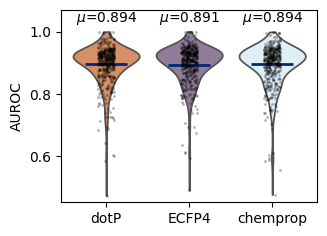

In [ ]:
means = (
    results_df
    .groupby("descriptor")["auroc"]
    .mean()
)

fig, ax = plt.subplots(figsize=(3.3, 2.5))  # width, height in inches

my_colors = ['#e68b56eb', '#92779eeb', '#dbf1faff']

ax = sns.violinplot(
    data=results_df,
    x="descriptor",
    y="auroc",
    inner=None,
    cut=0,
    ax=ax,
    palette=my_colors
)

sns.stripplot(
    data=results_df,
    x="descriptor",
    y="auroc",
    color="black",
    alpha=0.3,
    size=2,
    ax=ax
)

y_offset = 0.03 * (results_df["auroc"].max() - results_df["auroc"].min())

for i, descriptor in enumerate(means.index):
    ax.text(
        i,
        results_df["auroc"].max() + y_offset,
        f"$\mu$={means[descriptor]:.3f}",
        ha="center",
        va="bottom",
    )

for i, descriptor in enumerate(means.index):
    ax.hlines(
        means[descriptor],
        i - 0.25,
        i + 0.25,
        colors="#022778",
        linewidth=2
    )

ax.set_ylim(0.45,1.07)
ax.set_xlabel("")
# ax.set_title('Performance by dataset and descriptor')
ax.set_ylabel('AUROC')
plt.show()


# Figure 2 g (Figure 3.4.2 g)

### Distributions of molecules and pos:neg ratios per dataset

In [ ]:
ds_stats = results_df[['nmols', 'pos_neg_ratio', 'dataset']].drop_duplicates()

In [ ]:
ds_stats.sort_values(by='pos_neg_ratio', ascending=False)

,nmols,pos_neg_ratio,dataset
924,852,2.132353,231
964,895,1.983333,241
1176,566,1.932642,294
1188,585,1.925000,297
1420,582,1.924623,355
...,...,...,...
1008,23029,0.000739,252
628,13548,0.000739,157
1092,25374,0.000710,273
168,23250,0.000646,42


In [ ]:
ds_stats.describe()

,nmols,pos_neg_ratio,dataset
count,433.000000,433.000000,433.000000
mean,8324.011547,0.254940,216.000000
std,14241.466212,0.380535,125.140588
min,482.000000,0.000603,0.000000
25%,754.000000,0.019912,108.000000
50%,2075.000000,0.093560,216.000000
75%,8338.000000,0.324607,324.000000
max,73602.000000,2.132353,432.000000


In [ ]:
results_df[results_df['dataset']==231].sort_values(by='auroc', ascending=False).head(10)

,nmols,dataset,pos_neg_ratio,type,auroc,aupr,descriptor,species,median_max_similarity,maximum_similarity
924,852,231,2.132353,2,0.872688,0.934801,dotP,mycobacteriumtuberculosis,0.589603,1.0
926,852,231,2.132353,2,0.872046,0.923413,ECFP4,mycobacteriumtuberculosis,0.589603,1.0
925,852,231,2.132353,2,0.859504,0.925339,NMF,mycobacteriumtuberculosis,0.589603,1.0
927,852,231,2.132353,2,0.820693,0.900477,chemprop,mycobacteriumtuberculosis,0.589603,1.0


In [ ]:
ds_stats.shape

(433, 3)

In [ ]:
ds_stats

,nmols,pos_neg_ratio,dataset
0,519,0.067901,0
4,523,0.428962,1
8,519,0.070103,2
12,523,0.428962,3
16,753,0.394444,4
...,...,...,...
1712,675,0.057994,428
1716,674,0.018127,429
1720,742,0.170347,430
1724,742,0.064562,431


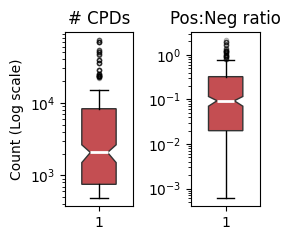

In [ ]:
color_ = "#C44E52"

fig, [ax1, ax2] = plt.subplots(1,2,figsize=(2.8, 2.5)) # Adjusted height for a single plot row

# 3. Create the Boxplot
bp = ax1.boxplot(ds_stats['nmols'], patch_artist=True, notch=True, 
                medianprops={'color': 'white', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
                widths=0.5)

# 4. Color the boxes
for patch, color in zip(bp['boxes'], [color_]):
    patch.set_facecolor(color)
    patch.set_edgecolor('#333333')

# 5. Grouping & Aesthetics
ax1.set_yscale("log")
ax1.set_ylabel("Count (Log scale)")
ax1.set_title("# CPDs")


# 3. Create the Boxplot
bp = ax2.boxplot(ds_stats['pos_neg_ratio'], patch_artist=True, notch=True, 
                medianprops={'color': 'white', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
                widths=0.5)

# 4. Color the boxes
for patch, color in zip(bp['boxes'], [color_]):
    patch.set_facecolor(color)
    patch.set_edgecolor('#333333')

# 5. Grouping & Aesthetics
ax2.set_yscale("log")
ax2.set_title("Pos:Neg ratio")

plt.tight_layout()
plt.show()


# Figure 2 i (Figure 3.4.2 i)

### Count  performance differences

In [ ]:
import pandas as pd
from itertools import combinations

# Group by species and dataset
aux = []
differences = 0.05
for metric in ["auroc", "aupr"]:
    for desc1, desc2 in combinations(results_df["descriptor"].unique(), 2):
        diff = results_df[results_df['descriptor']==desc1][metric].values - results_df[results_df['descriptor']==desc2][metric].values
        aux.append({
            "metric": metric,
            "descriptor_1": desc1,
            "descriptor_2": desc2,
            "count_1": sum(diff > differences),
            "count_2": sum(diff < -differences),
            "count_equal": len(diff) - sum(diff > differences) - sum(diff < -differences),
        })

In [ ]:
len([x for x in combinations(results_df["descriptor"].unique(), 2)])

3

In [ ]:
sum(diff<0.05)

np.int64(346)

In [ ]:
# Convert to DataFrame for inspection
diffs_df = pd.DataFrame(aux)
diffs_df.head()

,metric,descriptor_1,descriptor_2,count_1,count_2,count_equal
0,auroc,dotP,ECFP4,14,16,403
1,auroc,dotP,chemprop,27,13,393
2,auroc,ECFP4,chemprop,24,18,391
3,aupr,dotP,ECFP4,17,87,329
4,aupr,dotP,chemprop,56,93,284


In [ ]:
diffs_df

,metric,descriptor_1,descriptor_2,count_1,count_2,count_equal
0,auroc,dotP,ECFP4,14,16,403
1,auroc,dotP,chemprop,27,13,393
2,auroc,ECFP4,chemprop,24,18,391
3,aupr,dotP,ECFP4,17,87,329
4,aupr,dotP,chemprop,56,93,284
5,aupr,ECFP4,chemprop,87,49,297


In [ ]:
combinations_interest = [
    
    ('dotP', 'ECFP4'),
    ('dotP', 'chemprop'),
    ('dotP', 'NMF'),
    ('ECFP4', 'chemprop'),
    ('NMF', 'ECFP4'),
    ('chemprop', 'ECFP4'),
    ('chemprop', 'dotP'),
    ('chemprop', 'NMF'),
    ]

In [ ]:
diffs_df[diffs_df['metric']=='aupr'][['descriptor_1', 'descriptor_2']].apply(lambda x: f"{x['descriptor_1']} vs {x['descriptor_2']}", axis=1)

3        dotP vs ECFP4
4     dotP vs chemprop
5    ECFP4 vs chemprop
dtype: object

In [ ]:
diffs_df[diffs_df['metric'] == 'auroc'][['count_1', 'count_2']].shape

(3, 2)

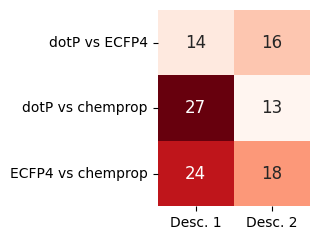

In [ ]:
fig, ax = plt.subplots(figsize=(3.3, 2.5))
sns.heatmap(diffs_df[diffs_df['metric'] == 'auroc'][['count_1', 'count_2']], ax=ax, annot=True, fmt='d', cbar=False, cmap='Reds',annot_kws={'size': 12})
ax.set_yticklabels(diffs_df[diffs_df['metric']=='auroc'][['descriptor_1', 'descriptor_2']].apply(lambda x: f"{x['descriptor_1']} vs {x['descriptor_2']}", axis=1), rotation=0)
# ax.set_title('# of datasets with\nperformance difference >0.05')
ax.set_xticklabels(['Desc. 1', 'Desc. 2'])
plt.tight_layout()
plt.show()